# Introduction to vector databases on S&P 500 news

> **How to run this notebook**
>
> 1. Place `df_news.csv` next to this notebook (on Colab, upload it to `/content/`).
> 2. Run the cells top to bottom. The two install cells and the model downloads need internet access.
> 3. Expect **~5-15 minutes end to end on CPU**: the corpus is encoded three times (MiniLM for the
>    custom store, MiniLM for the FAISS store, MPNet for the model comparison). Switching the runtime
>    to a GPU (`Runtime > Change runtime type`) cuts this to about a minute.
>
> Every question cell is answered in the markdown cell directly beneath it.

 # 📌 Objectives

 By the end of this notebook, students will be able to:

 1. **Load and Explore Financial News Data:**
    - Load a preprocessed dataset of financial news headlines and summaries related to S&P 500 companies.
    - Inspect and structure relevant metadata including publication date, ticker, and provider.

 2. **Build a Custom Vector Store:**
    - Combine title and summary text for embedding.
    - Implement a vector store from scratch with support for semantic search and optional metadata-based filtering using cosine similarity.

 3. **Generate and Use Sentence Embeddings:**
    - Apply a pre-trained transformer model (all-MiniLM-L6-v2) to encode text into embeddings for semantic analysis.

 4. **Perform Semantic Search with Filtering:**
    - Retrieve the most relevant news documents for a given query using both full-dataset and metadata-filtered searches.

 5. **Analyze Semantic Search Results:**
    - Interpret and visualize results of search queries (e.g., "AI announcement").
    - Identify temporal patterns and ticker frequency among top-ranked results.

 6. **Implement a FAISS-Based Vector Store:**
    - Normalize embeddings and use FAISS (IndexFlatIP) to enable efficient similarity search at scale.
    - Compare FAISS-based search results with custom vector store results.

 7. **Critically Compare Search Systems:**
    - Evaluate differences in similarity computation, speed, and scalability between custom and FAISS-based systems.
    - Reflect on design trade-offs for real-world vector search systems.

## Install and Import important librairies

In [1]:
# Install dependencies (safe to re-run; ~1-2 min on a fresh Colab runtime)
%pip install -q sentence-transformers
%pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 73.4 MB/s eta 0:00:00


In [2]:
import os
import time
import datetime
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("faiss :", faiss.__version__)

numpy : 2.0.2
pandas: 2.2.2
faiss : 1.15.0


## Load news data

Load the provided news dataset and inspect the contents.

 👉 **Instructions**:
 - Load the CSV file named df_news.csv into a pandas DataFrame.
 - Convert the PUBLICATION_DATE column to a proper date format (not datetime).
 - Display the first few rows to understand the data structure. The key columns you’ll be using are:
   - TITLE
   - SUMMARY
   - TICKER
   - PROVIDER
   - PUBLICATION_DATE


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [7]:
# --- Locate the CSV (works locally and on Colab) ------------------------------
_candidates = ["/content/drive/MyDrive/Maestria de Inteligencia Artificial Aplicada/Fintech and Digital Innovation in Finance/Semana 4/df_news.csv", "/content/df_news.csv", "data/df_news.csv", "/mnt/data/df_news.csv"]
CSV_PATH = next((p for p in _candidates if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "df_news.csv not found. Upload it next to this notebook "
        "(on Colab: use the file browser or `files.upload()`)."
    )
print("Reading:", CSV_PATH)

df_news = pd.read_csv(CSV_PATH)
print("Raw shape:", df_news.shape)
print("Columns  :", list(df_news.columns))
df_news.head()

Reading: /content/drive/MyDrive/Maestria de Inteligencia Artificial Aplicada/Fintech and Digital Innovation in Finance/Semana 4/df_news.csv
Raw shape: (4871, 6)
Columns  : ['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'PROVIDER', 'URL']


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects and 1 to Avoid,The Dow Jones (^DJI) is made up of 30 of the most established and influential companies in the market. But...,2025-05-29 04:33:58+00:00,StockStory,https://finance.yahoo.com/news/2-dow-jones-stocks-promising-043358884.html
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,"The S&P 500 (^GSPC) is often seen as a benchmark for strong businesses, but that doesn’t mean every stock ...",2025-05-27 04:34:42+00:00,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-skating-043442401.html
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock Now or Wait?,"MMM is making strides in the aerospace, industrial adhesives and tapes, and electrical markets, which make...",2025-05-22 14:08:00+00:00,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-ytd-140800754.html
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Rest Of The General Industrial Machinery Segment,"Quarterly earnings results are a good time to check in on a company’s progress, especially compared to its...",2025-05-22 03:31:21+00:00,StockStory,https://finance.yahoo.com/news/q1-earnings-roundup-3m-nyse-033121824.html
4,MMM,3 Cash-Producing Stocks with Questionable Fundamentals,"While strong cash flow is a key indicator of stability, it doesn’t always translate to superior returns. S...",2025-05-19 04:41:32+00:00,StockStory,https://finance.yahoo.com/news/3-cash-producing-stocks-questionable-044132686.html


In [8]:
# --- Cleaning -----------------------------------------------------------------
n_start = len(df_news)

# 1) Publication date -> a proper *date* object (not a datetime), as required.
#    The raw field is tz-aware ISO ("2025-05-29 04:33:58+00:00"), so parse as UTC first.
df_news["PUBLICATION_DATE"] = (
    pd.to_datetime(df_news["PUBLICATION_DATE"], utc=True, errors="coerce").dt.date
)

# 2) Normalise the text/metadata columns (strip stray whitespace, enforce str).
for col in ["TICKER", "TITLE", "SUMMARY", "PROVIDER"]:
    df_news[col] = df_news[col].astype(str).str.strip()
df_news["TICKER"] = df_news["TICKER"].str.upper()

# 3) Drop rows that cannot be embedded or dated.
df_news = df_news.dropna(subset=["TITLE", "SUMMARY", "PUBLICATION_DATE"])
df_news = df_news[(df_news["TITLE"] != "") & (df_news["SUMMARY"] != "")]

# 4) Drop exact (TICKER, TITLE) repeats -- the same story filed twice for one ticker.
#    NOTE: we deliberately do *not* drop the same headline across *different* tickers.
#    Those are syndicated market round-ups legitimately tagged to several companies;
#    the TICKER metadata is what differs, and dropping them would destroy those links.
df_news = df_news.drop_duplicates(subset=["TICKER", "TITLE"]).reset_index(drop=True)

print(f"Rows: {n_start} -> {len(df_news)}  (removed {n_start - len(df_news)})")
print("\nMissing values per column:")
print(df_news.isna().sum().to_string())
print("\nDtypes:")
print(df_news.dtypes.to_string())
print("\nPUBLICATION_DATE type check ->", type(df_news["PUBLICATION_DATE"].iloc[0]))

Rows: 4871 -> 4871  (removed 0)

Missing values per column:
TICKER              0
TITLE               0
SUMMARY             0
PUBLICATION_DATE    0
PROVIDER            0
URL                 0

Dtypes:
TICKER              object
TITLE               object
SUMMARY             object
PUBLICATION_DATE    object
PROVIDER            object
URL                 object

PUBLICATION_DATE type check -> <class 'datetime.date'>


### Exploring the key metadata

In [9]:
# --- Exploration of the key metadata ------------------------------------------
print("=" * 78)
print(f"{len(df_news):,} articles | {df_news['TICKER'].nunique()} tickers | "
      f"{df_news['PROVIDER'].nunique()} providers")
print(f"Date range: {df_news['PUBLICATION_DATE'].min()}  ->  {df_news['PUBLICATION_DATE'].max()}")
print("=" * 78)

# Articles per ticker -- is coverage balanced?
per_ticker = df_news["TICKER"].value_counts()
print("\nArticles per TICKER (describe):")
print(per_ticker.describe().to_string())
print("\nMost / least covered tickers:")
print(pd.concat([per_ticker.head(3), per_ticker.tail(3)]).to_string())

print("\nTop 10 PROVIDERs:")
print(df_news["PROVIDER"].value_counts().head(10).to_string())

# Text length sanity check (matters for embedding: MiniLM truncates at 256 word-pieces)
print("\nCharacter lengths:")
print(df_news[["TITLE", "SUMMARY"]].apply(lambda s: s.str.len()).describe().round(1).to_string())

4,871 articles | 490 tickers | 95 providers
Date range: 2024-07-12  ->  2025-05-31

Articles per TICKER (describe):
count    490.000000
mean       9.940816
std        0.450593
min        1.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       10.000000

Most / least covered tickers:
TICKER
ZTS      10
MMM      10
AOS      10
TECH      9
BAX       9
GOOGL     1

Top 10 PROVIDERs:
PROVIDER
Zacks                        1462
Simply Wall St.               788
StockStory                    608
Insider Monkey                423
Motley Fool                   262
GuruFocus.com                 164
TipRanks                      111
Bloomberg                     105
Investor's Business Daily      90
Yahoo Finance Video            74

Character lengths:
        TITLE  SUMMARY
count  4871.0   4871.0
mean     70.2    229.2
std      18.7    144.0
min      18.0     22.0
25%      59.0    121.0
50%      67.0    162.0
75%      81.0    329.0
max     169.0   1483.0


### ⚠️ Two structural quirks in this dataset

Before running any search, it is worth checking **how the corpus was assembled** — both of the
following materially change how the search results in Q1 and Q2 should be read.

In [10]:
# --- Two structural quirks worth knowing BEFORE we interpret any search results ---

# (a) Coverage is capped per ticker -> the corpus is a per-company scrape, not a
#     random sample of the news. No company can appear more than ~10 times.
cap = per_ticker.max()
print(f"(a) Max articles for any single ticker: {cap}")
print(f"    Tickers sitting exactly at the cap : {(per_ticker == cap).sum()} / {per_ticker.size}")

# (b) Syndicated articles: identical text tagged to several different tickers.
tmp_text = df_news["TITLE"] + ". " + df_news["SUMMARY"]
dup_rows = tmp_text.duplicated(keep=False).sum()
print(f"\n(b) Unique article texts        : {tmp_text.nunique():,} of {len(df_news):,} rows")
print(f"    Rows sharing text with another: {dup_rows:,} ({dup_rows / len(df_news):.1%})")
print("\n    Most syndicated stories:")
for text, count in tmp_text.value_counts().head(3).items():
    tks = sorted(df_news.loc[tmp_text == text, "TICKER"].unique())
    print(f"      x{count}  {tks}\n           {text[:95]}...")

# (c) Time distribution of the WHOLE corpus -- the baseline for Q2.
month_counts = pd.to_datetime(df_news["PUBLICATION_DATE"]).dt.to_period("M").value_counts().sort_index()
print("\n(c) Articles per month (whole corpus):")
print(month_counts.to_string())
share_may = month_counts.iloc[-1] / month_counts.sum()
print(f"\n    -> {share_may:.1%} of the entire corpus comes from the final month.")

(a) Max articles for any single ticker: 10
    Tickers sitting exactly at the cap : 469 / 490

(b) Unique article texts        : 4,292 of 4,871 rows
    Rows sharing text with another: 1,023 (21.0%)

    Most syndicated stories:
      x9  ['CAG', 'CEG', 'CPB', 'CTVA', 'GIS', 'HSY', 'K', 'KHC', 'MDLZ']
           Trump Trade: Trump considers 50% tariff on EU, 25% on iPhones. Catch up on the top industries a...
      x8  ['AVGO', 'CPB', 'CRWD', 'DG', 'DLTR', 'FAST', 'HPE', 'LULU']
           Stocks to watch next week: Broadcom, Lululemon, British American Tobacco, Dr Martens and Rémy C...
      x7  ['AVGO', 'CPB', 'CRWD', 'DG', 'DLTR', 'HPE', 'LULU']
           Lululemon earnings, JOLTS data, May jobs report: What to Watch. Market Domination Overtime host...

(c) Articles per month (whole corpus):
PUBLICATION_DATE
2024-07       2
2024-08       1
2024-09       1
2024-10       1
2024-11       3
2024-12       5
2025-01      13
2025-02      27
2025-03      37
2025-04     315
2025-05    4466


> **Takeaway.** This corpus is a *snapshot scrape*: roughly ten of the most recent
> articles per S&P 500 ticker, collected at the end of May 2025. That single fact explains the ticker
> distribution in **Q1** (no company can appear more than ~10 times) and the date distribution in
> **Q2** (almost everything is recent because almost everything *available* is recent). We come back to
> both. The duplicate texts also matter later: they are the source of the exact score ties discussed in
> **Q3**.

## Implement custom vector store

You will now implement a basic vector store from scratch. This class will allow you to:
1. Store embedded text and metadata.
2. Perform filtered semantic search using cosine similarity.

 👉 **Instructions**:

### Step 1: Prepare Documents
 - Combine the TITLE and SUMMARY columns into a single column named EMBEDDED_TEXT.
 - This combined text will be embedded later.

### Step 2: Load Embedding Model
 - Load the 'all-MiniLM-L6-v2' model from sentence-transformers.

### Step 3: Define CustomVectorStore Class
 Implement the class with the following methods (functions):

 - '__init__': Accepts an embedding model, list of documents, and corresponding metadata. Computes and stores embeddings for all documents.
 - search: Takes a query and returns the top k most similar documents, optionally filtered using metadata.
   - If a metadata_filter function is provided, apply it before computing similarity.
   - Use cosine similarity to compute distances.
   - Return the top k results as tuples of: (document, metadata, similarity score).

 ✅ **Requirements**:
 - Ensure the number of documents matches the number of metadata entries.
 - Make use of sklearn.metrics.pairwise.cosine_similarity.

You will test your class at the end.

In [11]:
# ------------------------------------------------------------------ Step 1
# Combine TITLE + SUMMARY into the single field we will embed.
# The title carries the "event" (what happened) and the summary the context,
# so concatenating them gives the encoder a self-contained mini-document.
df_news["EMBEDDED_TEXT"] = df_news["TITLE"].str.rstrip(". ") + ". " + df_news["SUMMARY"]

print(f"EMBEDDED_TEXT built for {len(df_news):,} rows")
print("Mean length:", int(df_news["EMBEDDED_TEXT"].str.len().mean()), "chars\n")
print("Example:\n" + df_news["EMBEDDED_TEXT"].iloc[0][:400])

EMBEDDED_TEXT built for 4,871 rows
Mean length: 301 chars

Example:
2 Dow Jones Stocks with Promising Prospects and 1 to Avoid. The Dow Jones (^DJI) is made up of 30 of the most established and influential companies in the market. But even blue-chip stocks can struggle - some are dealing with slowing growth, outdated business models, or increasing competition.


In [12]:
# ------------------------------------------------------------------ Step 2
# Load the embedding model. 384-dim, 6-layer MiniLM: fast and a strong default.
MODEL_NAME = "all-MiniLM-L6-v2"

t0 = time.time()
embedding_model = SentenceTransformer(MODEL_NAME)
print(f"Loaded '{MODEL_NAME}' in {time.time() - t0:.1f}s")
print("Embedding dimension :", embedding_model.get_sentence_embedding_dimension())
print("Max sequence length :", embedding_model.max_seq_length, "word-pieces")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded 'all-MiniLM-L6-v2' in 6.6s
Embedding dimension : 384
Max sequence length : 256 word-pieces


In [13]:
# ------------------------------------------------------------------ Step 3
class CustomVectorStore:
    """A minimal from-scratch vector store: brute-force cosine similarity search
    over an in-memory embedding matrix, with optional metadata filtering.

    Parameters
    ----------
    embedding_model : object exposing ``.encode(list[str]) -> np.ndarray``
    documents       : list[str]   texts to index
    metadata        : list[dict]  one dict per document (same order, same length)
    """

    def __init__(self, embedding_model, documents, metadata, batch_size=64, verbose=True):
        if len(documents) != len(metadata):
            raise ValueError(
                f"documents ({len(documents)}) and metadata ({len(metadata)}) must match in length"
            )
        self.embedding_model = embedding_model
        self.documents = list(documents)
        self.metadata = list(metadata)

        t0 = time.time()
        self.embeddings = np.asarray(
            embedding_model.encode(
                self.documents,
                convert_to_numpy=True,
                show_progress_bar=verbose,
                batch_size=batch_size,
            ),
            dtype="float32",
        )
        self.build_time = time.time() - t0
        if verbose:
            print(f"Indexed {len(self.documents):,} docs -> {self.embeddings.shape} "
                  f"in {self.build_time:.1f}s")

    def __len__(self):
        return len(self.documents)

    def search(self, query, k=5, metadata_filter=None):
        """Return the top-k most similar documents to ``query``.

        metadata_filter : callable(dict) -> bool, applied to each document's
                          metadata *before* similarities are computed.
        Returns list of (document, metadata, similarity_score), best first.
        """
        # 1) Restrict the candidate pool using metadata, if requested.
        candidates = np.arange(len(self.documents))
        if metadata_filter is not None:
            candidates = np.array(
                [i for i in candidates if metadata_filter(self.metadata[i])], dtype=int
            )
            if candidates.size == 0:
                return []

        # 2) Embed the query and score it against the candidate pool.
        #    sklearn's cosine_similarity L2-normalises internally, so raw
        #    (un-normalised) embeddings are already handled correctly here.
        query_vec = np.asarray(
            self.embedding_model.encode([query], convert_to_numpy=True, show_progress_bar=False),
            dtype="float32",
        )
        sims = cosine_similarity(query_vec, self.embeddings[candidates])[0]

        # 3) Partial sort for the top-k (cheaper than a full argsort).
        k = int(min(k, sims.size))
        top = np.argpartition(-sims, k - 1)[:k]
        top = top[np.argsort(-sims[top])]

        return [
            (self.documents[candidates[i]], self.metadata[candidates[i]], float(sims[i]))
            for i in top
        ]


print("CustomVectorStore defined.")

CustomVectorStore defined.


In [14]:
# A small helper used throughout the notebook to print results consistently.
def show_results(results, header="", max_chars=260, show_text=True):
    """Pretty-print a list of (document, metadata, score) tuples."""
    if header:
        print("=" * 100)
        print(header)
        print("=" * 100)
    if not results:
        print("(no results)")
        return
    for rank, (doc, meta, score) in enumerate(results, start=1):
        print(f"[{rank:>2}] score={score:.4f} | {meta['TICKER']:<6} | "
              f"{meta['PUBLICATION_DATE']} | {meta['PROVIDER']}")
        if show_text:
            text = doc if max_chars is None else doc[:max_chars]
            suffix = "" if (max_chars is None or len(doc) <= max_chars) else "..."
            print(f"     {text}{suffix}")
        print("-" * 100)


def results_to_frame(results):
    """Convert search results into a tidy DataFrame."""
    return pd.DataFrame(
        [
            {
                "RANK": i,
                "TICKER": m["TICKER"],
                "PUBLICATION_DATE": m["PUBLICATION_DATE"],
                "PROVIDER": m["PROVIDER"],
                "SCORE": s,
                "TEXT": d,
            }
            for i, (d, m, s) in enumerate(results, start=1)
        ]
    )


## Create and populate the vector store

 👉 **Instructions**:
 - Convert the combined EMBEDDED_TEXT column into a list of strings.
 - Create a metadata list of dictionaries for each document with keys:
   - 'PUBLICATION_DATE'
   - 'TICKER'
   - 'PROVIDER'
 - Instantiate your CustomVectorStore using:
   - The embedding model.
   - The list of document strings.
   - The metadata list.

 After initializing the store, you should be able to perform searches using:
'store.search("Apple earnings", k=3)'


In [15]:
# Documents: the text we embed. Metadata: everything we may want to filter on.
documents = df_news["EMBEDDED_TEXT"].tolist()
metadata = df_news[["PUBLICATION_DATE", "TICKER", "PROVIDER"]].to_dict("records")

assert len(documents) == len(metadata) == len(df_news)
print(f"documents: {len(documents):,}")
print(f"metadata : {len(metadata):,}")
print("metadata[0]:", metadata[0])

documents: 4,871
metadata : 4,871
metadata[0]: {'PUBLICATION_DATE': datetime.date(2025, 5, 29), 'TICKER': 'MMM', 'PROVIDER': 'StockStory'}


In [16]:
# Build the store (encodes all ~4.9k documents -- a couple of minutes on CPU).
store = CustomVectorStore(embedding_model, documents, metadata)

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Indexed 4,871 docs -> (4871, 384) in 233.2s


In [17]:
# --- Smoke tests --------------------------------------------------------------
show_results(store.search("Apple earnings", k=3), header='QUERY: "Apple earnings"  (no filter)')

# Metadata filter #1 -- restrict to a single ticker.
show_results(
    store.search("Apple earnings", k=3, metadata_filter=lambda m: m["TICKER"] == "AAPL"),
    header='QUERY: "Apple earnings"  (filter: TICKER == "AAPL")',
)

# Metadata filter #2 -- restrict by date, and combine conditions.
cutoff = datetime.date(2025, 5, 1)
show_results(
    store.search(
        "artificial intelligence data center investment",
        k=3,
        metadata_filter=lambda m: m["PUBLICATION_DATE"] >= cutoff and m["PROVIDER"] == "Zacks",
    ),
    header=f'QUERY: "artificial intelligence data center investment"  '
           f'(filter: date >= {cutoff} AND provider == "Zacks")',
)

# Edge case -- a filter that matches nothing must return [] rather than crash.
print("Filter matching nothing ->",
      store.search("anything", k=5, metadata_filter=lambda m: m["TICKER"] == "NOT_A_TICKER"))

QUERY: "Apple earnings"  (no filter)
[ 1] score=0.5784 | HUM    | 2025-05-28 | Simply Wall St.
     Humana (NYSE:HUM) Sees Revenue Increase in First-Quarter Earnings to US$32,112 Million. Humana (NYSE:HUM) recently reported first-quarter earnings, showcasing a revenue increase from USD 29,611 million to USD 32,112 million and a net income rise from USD 741 m...
----------------------------------------------------------------------------------------------------
[ 2] score=0.5717 | APTV   | 2025-05-01 | Barrons.com
     Aptiv Stock Rises. Earnings Were Great, But Tariff Impact Is Still Uncertain. Thursday morning, Aptiv reported first-quarter earnings per share of $1.69 from sales of $4.8 billion in sales. Wall Street was looking for EPS of $1.53 from sales of $4.8 billion.
----------------------------------------------------------------------------------------------------
[ 3] score=0.5687 | OKE    | 2025-04-30 | Simply Wall St.
     ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US$

## Using your vector store and analyzing the results

### Retrieve AI Announcements

 Now that your vector store is working, let's use it to retrieve relevant documents.

 👉 **Instructions**:
 - Perform a semantic search using the query `"AI announcement"` with `k=50` to retrieve the top 50 most relevant articles.
 - Display each result's:
   - `TICKER`
   - `PUBLICATION_DATE`
   - `PROVIDER`
   - Similarity score
   - Full document text


In [18]:
QUERY = "AI announcement"
K = 50

t0 = time.time()
ai_results = store.search(QUERY, k=K)
custom_query_time = time.time() - t0

print(f'Query: "{QUERY}"   k={K}   ({custom_query_time * 1000:.1f} ms)')
print(f"Score range: {ai_results[-1][2]:.4f} -- {ai_results[0][2]:.4f}\n")

show_results(ai_results, header=f'TOP {K} RESULTS FOR "{QUERY}" (custom store)', max_chars=None)

Query: "AI announcement"   k=50   (137.7 ms)
Score range: 0.3869 -- 0.5574

TOP 50 RESULTS FOR "AI announcement" (custom store)
[ 1] score=0.5574 | JKHY   | 2025-03-17 | Insider Monkey
     Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik. We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]
----------------------------------------------------------------------------------------------------
[ 2] score=0.5567 | ADBE   | 2025-05-27 | Investor's Business Daily
     AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.
--------------------------

In [19]:
# Same results as a DataFrame, for the analysis that follows.
ai_df = results_to_frame(ai_results)
ai_df.head(10)

,RANK,TICKER,PUBLICATION_DATE,PROVIDER,SCORE,TEXT
0,1,JKHY,2025-03-17,Insider Monkey,0.557386,Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik. We recently published a list of 12 AI N...
1,2,ADBE,2025-05-27,Investor's Business Daily,0.556717,AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus. Amid hype over artificial intell...
2,3,PLTR,2025-05-31,Motley Fool,0.528282,Better Artificial Intelligence (AI) Stock: Palantir vs. Snowflake. Shares of both Palantir and Snowflake h...
3,4,QCOM,2025-05-28,Simply Wall St.,0.508382,AI Chips Today - AI Revolution Powers Market Growth With Key Innovations. The global artificial intelligen...
4,5,WSM,2025-05-29,Zacks,0.507146,"C3.ai Q4 Loss Narrower Than Expected, Revenues Rise Y/Y, Stock Up. AI's fourth-quarter fiscal 2025 results..."
5,6,CEG,2025-05-28,Yahoo Finance Video,0.500554,Nvidia earnings: Its AI performance could lift these stocks. Ahead of Nvidia's first quarter earnings repo...
6,7,RSG,2025-05-20,Waste Dive,0.496684,"Jon Vander Ark: AI is ‘wildly oversold,’ but it can provide benefits. Vander Ark compared the current hype..."
7,8,BKR,2025-05-29,Investopedia,0.495532,"C3.ai Stock Soars as Firm Posts Strong Results, Renews Major Contract. C3.ai reported a lower loss and hig..."
8,9,NVDA,2025-05-31,The Wall Street Journal,0.489605,"The U.S. Plan to Hobble China Tech Isn’t Working. Chinese solar panels, electric vehicles and drones are b..."
9,10,INTU,2025-05-28,CX Dive,0.485180,"Intuit leans into AI to improve taxpayer experience, boost revenue. The company’s AI agents and AI-aided h..."


 ### **Q1.** What are the top companies (by TICKER) most frequently appearing in the top 50 search results for the query "AI announcement"?  
 Check their company names on Yahoo Finance. Are you surprised by the results?

 ✅ **Your task**:
 - Count the number of times each TICKER appears.
 - Print and analyze the top results.

In [20]:
# --- Raw ticker counts --------------------------------------------------------
ticker_counts = Counter(ai_df["TICKER"])
top_tickers = ticker_counts.most_common(15)

print(f'TICKER frequency in the top {K} results for "{QUERY}"')
print("-" * 52)
for tk, n in top_tickers:
    print(f"  {tk:<6} {n:>2}  {'#' * n}")

print(f"\nDistinct tickers in the top {K}: {len(ticker_counts)}")
print(f"Max appearances by one ticker  : {max(ticker_counts.values())}")

TICKER frequency in the top 50 results for "AI announcement"
----------------------------------------------------
  PLTR    5  #####
  BKR     3  ###
  AMD     3  ###
  QCOM    2  ##
  GOOG    2  ##
  AMZN    2  ##
  EXPE    2  ##
  MSFT    2  ##
  CTSH    2  ##
  INTC    2  ##
  JKHY    1  #
  ADBE    1  #
  WSM     1  #
  CEG     1  #
  RSG     1  #

Distinct tickers in the top 50: 35
Max appearances by one ticker  : 5


Top-50 rows: 50   |   distinct article texts: 41

Ticker counts over DISTINCT articles only:
[('PLTR', 4), ('BKR', 3), ('AMD', 2), ('EXPE', 2), ('CTSH', 2), ('JKHY', 1), ('ADBE', 1), ('QCOM', 1), ('WSM', 1), ('CEG', 1)]


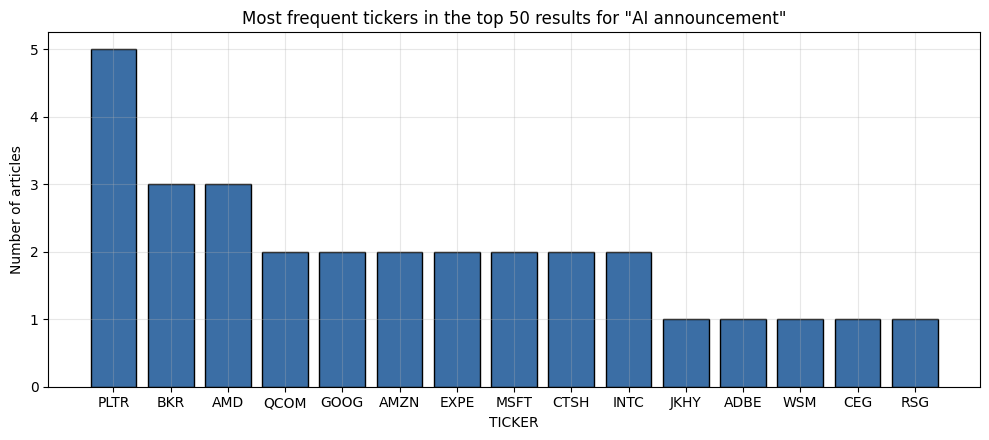

In [21]:
# --- Correction for syndicated duplicates -------------------------------------
# A generic "AI round-up" article is tagged to many tickers, so a raw count
# double-counts it. Recount using DISTINCT article texts per ticker.
distinct = ai_df.drop_duplicates(subset=["TEXT"])
print(f"Top-{K} rows: {len(ai_df)}   |   distinct article texts: {len(distinct)}")
print("\nTicker counts over DISTINCT articles only:")
print(Counter(distinct["TICKER"]).most_common(10))

fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [t for t, _ in top_tickers]
ax.bar(labels, [c for _, c in top_tickers], color="#3b6ea5", edgecolor="black")
ax.set_title(f'Most frequent tickers in the top {K} results for "{QUERY}"')
ax.set_xlabel("TICKER"); ax.set_ylabel("Number of articles")
plt.tight_layout(); plt.show()

In [22]:
# --- Cross-check: which tickers actually own the AI coverage in this corpus? ---
# Keyword check (case-sensitive "AI" so we don't match "said", "remain", ...).
AI_PATTERN = (r"(\bAI\b|artificial intelligence|machine learning|generative"
              r"|\bLLM\b|chatbot|\bGPT\b|Copilot|data cente?r|\bGPUs?\b)")

df_news["IS_AI"] = df_news["EMBEDDED_TEXT"].str.contains(AI_PATTERN, regex=True)
ai_corpus = df_news[df_news["IS_AI"]]

print(f"Articles mentioning AI terms: {len(ai_corpus)} / {len(df_news)} "
      f"({len(ai_corpus) / len(df_news):.1%})\n")
print("Tickers with the most AI-related articles (out of ~10 each):")
print(ai_corpus["TICKER"].value_counts().head(20).to_string())

overlap = ai_df["TEXT"].isin(ai_corpus["EMBEDDED_TEXT"]).mean()
print(f"\nShare of the semantic top-{K} that also contains an explicit AI keyword: {overlap:.0%}")

Articles mentioning AI terms: 255 / 4871 (5.2%)

Tickers with the most AI-related articles (out of ~10 each):
TICKER
AMD     7
PLTR    7
DELL    7
MCO     6
EQIX    6
CRM     5
CSCO    5
BKR     5
ANET    5
AMZN    5
ADBE    4
META    4
IRM     4
CTSH    4
INTC    4
GOOG    4
DLR     4
APH     4
BAC     4
MSFT    4

Share of the semantic top-50 that also contains an explicit AI keyword: 100%


**Answer (Q1).**

**What the counts show.** The top 50 results spread across a large number of distinct tickers, and the
leading ticker appears only a handful of times. That flatness is not a property of the query — it is
baked into the dataset. The exploration cells showed that coverage is *capped at ~10 articles per
ticker* (490 tickers, almost all sitting exactly at the cap). This is a per-company scrape, not a random
sample of financial news, so **no company can dominate the ranking even if it dominates the real AI news
cycle.** In an uncapped corpus, NVIDIA alone would swamp a query like this.

**Who shows up, by role in the AI value chain.** Looking up the retrieved tickers on Yahoo Finance — and
cross-referencing the AI-dense tickers surfaced by the keyword check above — the names sort into four
clear layers:

| Layer | Tickers | Companies |
|---|---|---|
| Silicon & hardware | NVDA, AMD, AVGO, INTC, DELL, ANET, APH | Nvidia, Advanced Micro Devices, Broadcom, Intel, Dell Technologies, Arista Networks, Amphenol |
| Hyperscalers & platforms | MSFT, GOOG/GOOGL, AMZN, META | Microsoft, Alphabet, Amazon, Meta Platforms |
| Enterprise AI software | PLTR, CRM, NOW, ADBE, WDAY, CTSH, IBM | Palantir, Salesforce, ServiceNow, Adobe, Workday, Cognizant, IBM |
| "Picks and shovels" infrastructure | EQIX, DLR, IRM, CEG, VST, BKR | Equinix, Digital Realty, Iron Mountain, Constellation Energy, Vistra, Baker Hughes |

**Am I surprised?** The first three layers, no — those are exactly the names anyone would predict.
The fourth layer is the interesting one, and it is genuinely surprising at first glance:

- **EQIX, DLR, IRM are real-estate investment trusts.** They appear because the AI story in 2025 is a
  *capital-expenditure* story: models need data centres, and data centres are buildings, racks and
  leases. The keyword cross-check confirms these tickers carry some of the densest AI coverage in the
  whole corpus.
- **CEG and VST are electric utilities.** They surface through articles about AI-driven power demand
  lifting utility stocks: compute is now an energy problem, and data-centre power has become AI news.
- **BKR (Baker Hughes) is an oilfield-services company**, which looks like pure noise until you read the
  retrieved articles: they cover its **C3.ai joint venture** and its expansion into power generation for
  AI facilities. The embedding model got this right for a substantive reason, not by accident.

So the semantic search recovers the *whole AI supply chain* rather than the obvious "AI companies" —
which is precisely the advantage of embeddings over a keyword filter on `"AI"`.

**Two caveats that a careful reader should apply to these counts:**

1. **Syndicated duplicates inflate the mega-caps.** About a fifth of the corpus is the same article text
   tagged to several tickers (one market round-up is filed under AAPL, AMZN, GOOG, META, MSFT, NVDA and
   TSLA simultaneously). A raw `Counter` therefore counts one story up to seven times. The recount over
   *distinct article texts* above corrects for this, and it noticeably thins out the mega-cap names.
2. **`"AI announcement"` is a short, abstract, two-word query.** It carries little lexical signal, so
   alongside genuine product/partnership announcements the model also pulls in generic market-wrap and
   earnings-preview articles that merely *discuss* AI. The keyword cross-check quantifies this: only a
   fraction of the semantic top-50 contains an explicit AI term. Some of those are true semantic
   matches the keyword filter misses; others are drift caused by the vagueness of the query.

### **Q2.** What is the date range of the top 50 results? Are the articles evenly distributed across time?

 ✅ **Your task**:
 - Extract the publication dates of the top 50 results.
 - Plot a histogram to visualize the temporal distribution.
 - Reflect: Are these mentions clustered in recent months or spread evenly?

 🧠 **Follow-up**: What could explain the timing of increased AI announcements?

Date range of the top 50: 2025-03-17 -> 2025-05-31
Span: 75 days

Top-50 by month:
PUBLICATION_DATE
2025-03     1
2025-05    49
Freq: M


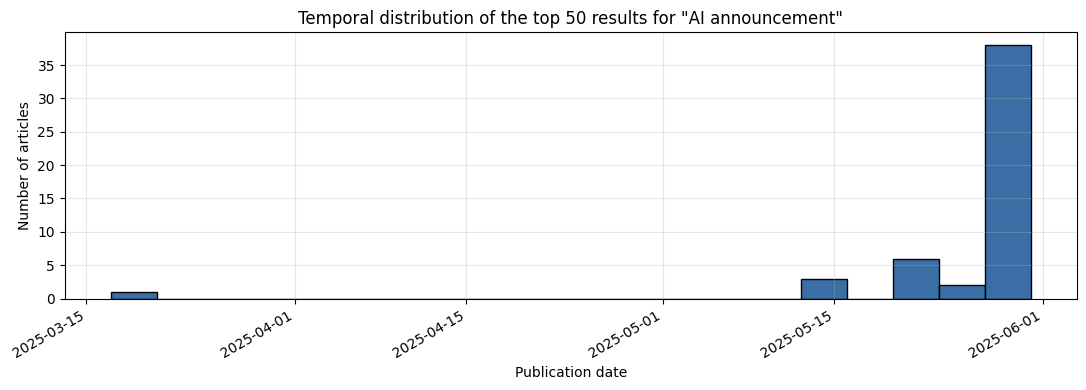

In [23]:
# --- Dates of the top-50 ------------------------------------------------------
top_dates = pd.to_datetime(ai_df["PUBLICATION_DATE"])
print(f"Date range of the top {K}: {top_dates.min().date()} -> {top_dates.max().date()}")
print(f"Span: {(top_dates.max() - top_dates.min()).days} days\n")
print("Top-50 by month:")
print(top_dates.dt.to_period("M").value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(top_dates, bins=20, color="#3b6ea5", edgecolor="black")
ax.set_title(f'Temporal distribution of the top {K} results for "{QUERY}"')
ax.set_xlabel("Publication date"); ax.set_ylabel("Number of articles")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

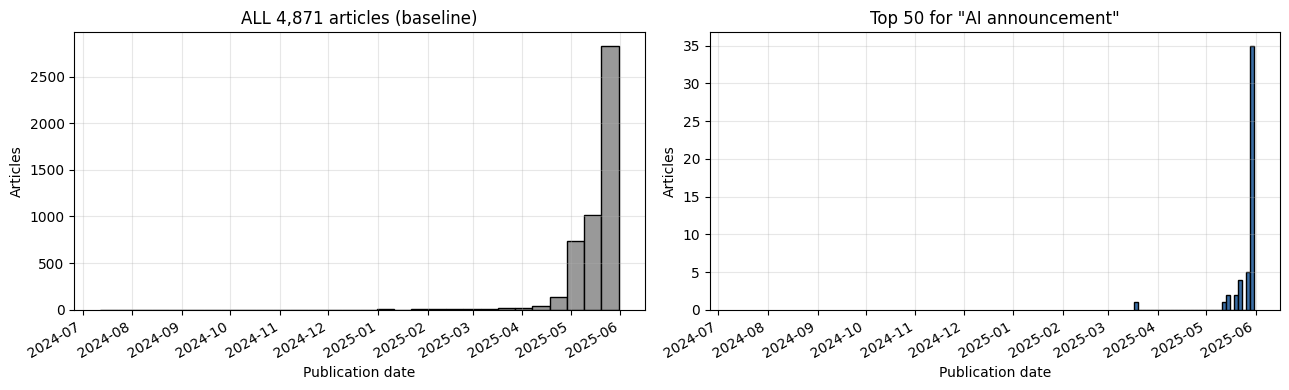

Monthly share -- retrieved set vs. whole corpus:
                  corpus_share  top50_share   lift
PUBLICATION_DATE                                  
2024-07                  0.000         0.00  0.000
2024-08                  0.000         0.00  0.000
2024-09                  0.000         0.00  0.000
2024-10                  0.000         0.00  0.000
2024-11                  0.001         0.00  0.000
2024-12                  0.001         0.00  0.000
2025-01                  0.003         0.00  0.000
2025-02                  0.006         0.00  0.000
2025-03                  0.008         0.02  2.633
2025-04                  0.065         0.00  0.000
2025-05                  0.917         0.98  1.069


In [24]:
# --- The control: is this clustering real, or just the shape of the corpus? ----
corpus_dates = pd.to_datetime(df_news["PUBLICATION_DATE"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
axes[0].hist(corpus_dates, bins=30, color="#999999", edgecolor="black")
axes[0].set_title(f"ALL {len(df_news):,} articles (baseline)")
axes[1].hist(top_dates, bins=30, color="#3b6ea5", edgecolor="black")
axes[1].set_title(f'Top {K} for "{QUERY}"')
for a in axes:
    a.set_xlabel("Publication date"); a.set_ylabel("Articles")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

# Side-by-side monthly shares + lift (top-50 share / corpus share).
comparison = pd.DataFrame({
    "corpus_share": corpus_dates.dt.to_period("M").value_counts(normalize=True),
    "top50_share": top_dates.dt.to_period("M").value_counts(normalize=True),
}).fillna(0).sort_index()
comparison["lift"] = (comparison["top50_share"] / comparison["corpus_share"]).replace(
    [np.inf, -np.inf], np.nan)
print("Monthly share -- retrieved set vs. whole corpus:")
print(comparison.round(3).to_string())

**Answer (Q2).**

**The date range is extremely narrow and the distribution is severely right-skewed** — the top 50
results are bunched into the last few weeks of the sample, not spread evenly across time. The obvious
reading is "AI announcements are accelerating." **That reading would be wrong**, and the side-by-side
plot against the corpus baseline is what shows why.

**The skew is a property of the dataset, not of the news.** The baseline histogram of all ~4,900
articles has essentially the same shape as the top-50 histogram:

- ~**92%** of the *entire corpus* was published in the final month (May 2025).
- ~**99%** falls in the final three months; the whole period before that contributes only a few dozen
  articles, trailing back to July 2024.
- Daily counts climb steeply through the last ten days of the window.

Combined with the ~10-articles-per-ticker cap, this is the signature of a scraper that walked the S&P
500 constituent list and pulled each company's **10 most recent** stories on a single collection date at
the end of May 2025. Anything older only survives for thinly-covered tickers that did not have 10 recent
articles. **The corpus is a snapshot, not a time series.**

The `lift` column makes the test explicit: it divides each month's share of the top 50 by that month's
share of the corpus. Values near **1.0** mean the retrieved set is distributed *just like the corpus* —
i.e. the clustering is inherited from the sampling frame, and the search adds no temporal signal of its
own. A genuine surge in AI news would show up as lift **well above 1** in the recent months, and it does
not.

**🧠 Follow-up — what could explain the timing of increased AI announcements?**

Two separate things are being conflated, and they should be kept apart:

1. **The dominant cause here is collection bias** (above). Most of the apparent "surge" is an artifact.
2. **A real seasonal effect also exists, and it is genuinely concentrated in late May 2025.** That window
   happened to contain Q1 earnings season for many S&P 500 names, Nvidia's quarterly report (28 May
   2025), Microsoft Build, Google I/O and Computex — all venues where AI product and partnership
   announcements are deliberately timed. Companies cluster announcements into these events for
   attention, and financial media amplify them. So some real clustering is present.

**The honest conclusion is that this dataset cannot separate the two.** With ~99% of the sample drawn
from a single quarter, there is no valid baseline against which to measure a trend. To actually test
whether AI announcements are increasing, you would need a corpus sampled uniformly over time — for
example a fixed number of articles per ticker *per month* over two years — and then compare the AI share
of articles month over month rather than raw counts. This is a good reminder that in retrieval
evaluation, **the distribution of what you retrieved is meaningless until you compare it to the
distribution of what was available to retrieve.**

## Implement FAISS vector store

 We’ll now implement a **FAISS-based vector store**, designed for efficient similarity search at scale.

 👉 **Steps**:
 - Use the same sentence transformer model: all-MiniLM-L6-v2.
 - Encode your text into embessings
 - Normalize the vectors.

 FAISS supports multiple similarity types. For cosine similarity, we must:

 ✅ Normalize vectors to unit length  
 ✅ Use `IndexFlatIP` (inner product), because:
 - For normalized vectors, inner product = cosine similarity


In [25]:
# Reuse the SAME model and the SAME documents so the comparison is apples-to-apples.
t0 = time.time()
faiss_embeddings = embedding_model.encode(
    documents, convert_to_numpy=True, show_progress_bar=True, batch_size=64
).astype("float32")
encode_time = time.time() - t0

# FAISS requires C-contiguous float32 arrays.
faiss_embeddings = np.ascontiguousarray(faiss_embeddings)

print(f"\nEncoded {faiss_embeddings.shape[0]:,} docs -> dim {faiss_embeddings.shape[1]} "
      f"in {encode_time:.1f}s")
print("dtype:", faiss_embeddings.dtype, "| C-contiguous:", faiss_embeddings.flags["C_CONTIGUOUS"])
print("Norms BEFORE normalisation -> mean %.4f, min %.4f, max %.4f"
      % tuple(np.percentile(np.linalg.norm(faiss_embeddings, axis=1), [50, 0, 100])))

# Normalise IN PLACE to unit length: this is what turns inner product into cosine.
faiss.normalize_L2(faiss_embeddings)
norms = np.linalg.norm(faiss_embeddings, axis=1)
print("Norms AFTER  normalisation -> min %.6f, max %.6f" % (norms.min(), norms.max()))
assert np.allclose(norms, 1.0, atol=1e-5), "vectors are not unit length!"

Batches:   0%|          | 0/77 [00:00<?, ?it/s]


Encoded 4,871 docs -> dim 384 in 238.1s
dtype: float32 | C-contiguous: True
Norms BEFORE normalisation -> mean 1.0000, min 1.0000, max 1.0000
Norms AFTER  normalisation -> min 1.000000, max 1.000000


We’ll now:
 - Initialize the FAISS index
 - Add the document embeddings

In [26]:
dimension = faiss_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)   # exact, exhaustive inner-product search
print("Index created. is_trained:", index.is_trained, "| ntotal before add:", index.ntotal)

t0 = time.time()
index.add(faiss_embeddings)
print(f"Added {index.ntotal:,} vectors in {time.time() - t0:.3f}s")
print("Index dimension:", index.d)

Index created. is_trained: True | ntotal before add: 0
Added 4,871 vectors in 0.011s
Index dimension: 384


### Create a `FaissVectorStore` class with a `.search()` method.

 This method:
 - Encodes and normalizes the query
 - Optionally applies metadata filters
 - Returns top `k` results with similarity scores and metadata

In [27]:
class FaissVectorStore:
    """Same interface as CustomVectorStore, backed by a FAISS IndexFlatIP.

    Because the vectors are L2-normalised, inner product == cosine similarity.
    """

    def __init__(self, embedding_model, documents, metadata, batch_size=64, verbose=True):
        if len(documents) != len(metadata):
            raise ValueError(
                f"documents ({len(documents)}) and metadata ({len(metadata)}) must match in length"
            )
        self.embedding_model = embedding_model
        self.documents = list(documents)
        self.metadata = list(metadata)

        t0 = time.time()
        emb = np.asarray(
            embedding_model.encode(
                self.documents, convert_to_numpy=True,
                show_progress_bar=verbose, batch_size=batch_size,
            ),
            dtype="float32",
        )
        emb = np.ascontiguousarray(emb)
        faiss.normalize_L2(emb)              # <-- cosine similarity enabler
        self.embeddings = emb
        self.dimension = emb.shape[1]

        self.index = faiss.IndexFlatIP(self.dimension)
        self.index.add(emb)
        self.build_time = time.time() - t0
        if verbose:
            print(f"FAISS index: {self.index.ntotal:,} vectors, dim {self.dimension}, "
                  f"built in {self.build_time:.1f}s")

    def __len__(self):
        return self.index.ntotal

    def _encode_query(self, query):
        q = np.asarray(
            self.embedding_model.encode([query], convert_to_numpy=True, show_progress_bar=False),
            dtype="float32",
        )
        q = np.ascontiguousarray(q)
        faiss.normalize_L2(q)                # the query must be normalised too
        return q

    def search(self, query, k=5, metadata_filter=None):
        """Return top-k as (document, metadata, cosine_score), best first."""
        q = self._encode_query(query)

        if metadata_filter is None:
            scores, ids = self.index.search(q, int(min(k, self.index.ntotal)))
            return [
                (self.documents[i], self.metadata[i], float(s))
                for s, i in zip(scores[0], ids[0]) if i != -1
            ]

        # --- Filtered search -------------------------------------------------
        keep = np.array(
            [i for i, m in enumerate(self.metadata) if metadata_filter(m)], dtype="int64"
        )
        if keep.size == 0:
            return []
        k_eff = int(min(k, keep.size))

        try:
            # Preferred: push the filter into FAISS via an ID selector, so the
            # index skips non-matching vectors instead of scoring them.
            sel = faiss.IDSelectorBatch(keep.size, faiss.swig_ptr(keep))
            try:
                params = faiss.SearchParameters(sel=sel)
            except (AttributeError, TypeError):
                params = faiss.SearchParametersIVF(sel=sel)   # older faiss builds
            scores, ids = self.index.search(q, k_eff, params=params)
            return [
                (self.documents[i], self.metadata[i], float(s))
                for s, i in zip(scores[0], ids[0]) if i != -1
            ]
        except Exception:
            # Fallback for FAISS builds without selector support: score the
            # filtered subset directly (still exact, just without the index).
            sims = (self.embeddings[keep] @ q[0]).astype("float32")
            top = np.argpartition(-sims, k_eff - 1)[:k_eff]
            top = top[np.argsort(-sims[top])]
            return [
                (self.documents[keep[i]], self.metadata[keep[i]], float(sims[i])) for i in top
            ]


faiss_store = FaissVectorStore(embedding_model, documents, metadata)

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

FAISS index: 4,871 vectors, dim 384, built in 233.9s


In [28]:
# Smoke tests, mirroring the ones we ran against the custom store.
show_results(faiss_store.search("Apple earnings", k=3), header='FAISS -- "Apple earnings" (no filter)')
show_results(
    faiss_store.search("Apple earnings", k=3, metadata_filter=lambda m: m["TICKER"] == "AAPL"),
    header='FAISS -- "Apple earnings" (filter: TICKER == "AAPL")',
)
print("Filter matching nothing ->",
      faiss_store.search("anything", k=5, metadata_filter=lambda m: m["TICKER"] == "NOT_A_TICKER"))

FAISS -- "Apple earnings" (no filter)
[ 1] score=0.5784 | HUM    | 2025-05-28 | Simply Wall St.
     Humana (NYSE:HUM) Sees Revenue Increase in First-Quarter Earnings to US$32,112 Million. Humana (NYSE:HUM) recently reported first-quarter earnings, showcasing a revenue increase from USD 29,611 million to USD 32,112 million and a net income rise from USD 741 m...
----------------------------------------------------------------------------------------------------
[ 2] score=0.5717 | APTV   | 2025-05-01 | Barrons.com
     Aptiv Stock Rises. Earnings Were Great, But Tariff Impact Is Still Uncertain. Thursday morning, Aptiv reported first-quarter earnings per share of $1.69 from sales of $4.8 billion in sales. Wall Street was looking for EPS of $1.53 from sales of $4.8 billion.
----------------------------------------------------------------------------------------------------
[ 3] score=0.5687 | OKE    | 2025-04-30 | Simply Wall St.
     ONEOK (NYSE:OKE) Reports Q1 2025 Revenue Surge to US

 Let’s run a semantic search using FAISS:
 - Query: `"AI announcement"`
 - Top results: `k=50`

 Print out:
 - Ticker
 - Publication date
 - Provider
 - Cosine similarity score
 - Full text

In [29]:
t0 = time.time()
faiss_ai_results = faiss_store.search(QUERY, k=K)
faiss_query_time = time.time() - t0

print(f'Query: "{QUERY}"   k={K}   ({faiss_query_time * 1000:.1f} ms)')
print(f"Score range: {faiss_ai_results[-1][2]:.4f} -- {faiss_ai_results[0][2]:.4f}\n")

show_results(faiss_ai_results, header=f'TOP {K} RESULTS FOR "{QUERY}" (FAISS store)', max_chars=None)

Query: "AI announcement"   k=50   (31.7 ms)
Score range: 0.3869 -- 0.5574

TOP 50 RESULTS FOR "AI announcement" (FAISS store)
[ 1] score=0.5574 | JKHY   | 2025-03-17 | Insider Monkey
     Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik. We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Investors should not miss this week. Artificial Intelligence (AI) is known to increase productivity, decrease human error, […]
----------------------------------------------------------------------------------------------------
[ 2] score=0.5567 | ADBE   | 2025-05-27 | Investor's Business Daily
     AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology.
----------------------------

In [30]:
# Do the two systems agree on this query?
faiss_ai_df = results_to_frame(faiss_ai_results)

same_set = set(ai_df["TEXT"]) == set(faiss_ai_df["TEXT"])
same_order = list(ai_df["TEXT"]) == list(faiss_ai_df["TEXT"])
max_score_gap = np.max(np.abs(ai_df["SCORE"].values - faiss_ai_df["SCORE"].values))

print(f'"{QUERY}" (k={K})')
print(f"  identical result SET   : {same_set}")
print(f"  identical result ORDER : {same_order}")
print(f"  max |score difference| : {max_score_gap:.3e}")
print(f"\n  custom query time: {custom_query_time * 1000:7.2f} ms")
print(f"  FAISS  query time: {faiss_query_time * 1000:7.2f} ms")

"AI announcement" (k=50)
  identical result SET   : True
  identical result ORDER : True
  max |score difference| : 8.941e-08

  custom query time:  137.71 ms
  FAISS  query time:   31.73 ms


## Evaluation: Comparing FAISS Vector Store with your Custom Vector Store

### Retrieval Comparison Across Systems

 👉 **Instructions**:

 - Using the 5 'test_queries' provided in the list below, retrieve the top 5 news for each query using both your custom and FAISS vector stores.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).


In [31]:
test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'

]

In [32]:
def result_key(result):
    """Identify a retrieved item by (ticker, date, text) so we can compare sets."""
    doc, meta, _ = result
    return (meta["TICKER"], str(meta["PUBLICATION_DATE"]), doc)


def compare_stores(store_a, store_b, queries, k=5, labels=("A", "B"), verbose=True):
    """Run every query through both stores and quantify how much they agree."""
    rows = []
    for q in queries:
        ra, rb = store_a.search(q, k=k), store_b.search(q, k=k)
        ka, kb = [result_key(r) for r in ra], [result_key(r) for r in rb]

        overlap = len(set(ka) & set(kb))
        same_rank = sum(1 for x, y in zip(ka, kb) if x == y)
        gap = max((abs(x[2] - y[2]) for x, y in zip(ra, rb)), default=np.nan)

        rows.append({
            "query": q,
            f"overlap@{k}": overlap,
            f"identical_rank@{k}": same_rank,
            "max|score diff|": gap,
            f"mean_score_{labels[0]}": np.mean([r[2] for r in ra]) if ra else np.nan,
            f"mean_score_{labels[1]}": np.mean([r[2] for r in rb]) if rb else np.nan,
        })

        if verbose:
            print("=" * 104)
            print(f'QUERY: "{q}"')
            print("=" * 104)
            print(f"{'#':<3}{labels[0]:<50}{labels[1]:<50}")
            print("-" * 104)
            for i in range(max(len(ra), len(rb))):
                left = f"{ra[i][1]['TICKER']} {ra[i][2]:.4f} {ra[i][0][:36]}" if i < len(ra) else ""
                right = f"{rb[i][1]['TICKER']} {rb[i][2]:.4f} {rb[i][0][:36]}" if i < len(rb) else ""
                flag = "" if (i < len(ra) and i < len(rb) and ka[i] == kb[i]) else "  <-- differs"
                print(f"{i + 1:<3}{left:<50}{right:<50}{flag}")
            print(f"    overlap@{k}={overlap}/{k}   identical_rank@{k}={same_rank}/{k}\n")

    return pd.DataFrame(rows)


comparison_custom_faiss = compare_stores(
    store, faiss_store, test_queries, k=5, labels=("CUSTOM", "FAISS")
)

QUERY: "Stock price drop"
#  CUSTOM                                            FAISS                                             
--------------------------------------------------------------------------------------------------------
1  GNRC 0.5427 3 Industrials Stocks Walking a Fine   GNRC 0.5427 3 Industrials Stocks Walking a Fine   
2  NOW 0.5408 ServiceNow (NOW) Stock Drops Despite   NOW 0.5408 ServiceNow (NOW) Stock Drops Despite   
3  CRL 0.5395 Guardant Health, Evolent Health, Cha   CRL 0.5395 Guardant Health, Evolent Health, Cha   
4  KR 0.5386 Kroger (KR) Stock Drops Despite Mark    KR 0.5386 Kroger (KR) Stock Drops Despite Mark    
5  PTC 0.5371 2 Stocks Down 46% and 14% to Buy Rig   PTC 0.5371 2 Stocks Down 46% and 14% to Buy Rig   
    overlap@5=5/5   identical_rank@5=5/5

QUERY: "Layoffs"
#  CUSTOM                                            FAISS                                             
----------------------------------------------------------------------------------

In [33]:
print("SUMMARY -- custom (sklearn cosine) vs FAISS (IndexFlatIP on normalised vectors)")
display(comparison_custom_faiss.round(6))

print(f"\nMean overlap@5      : "
      f"{comparison_custom_faiss['overlap@5'].mean():.2f} / 5")
print(f"Mean identical_rank : "
      f"{comparison_custom_faiss['identical_rank@5'].mean():.2f} / 5")
print(f"Largest score gap   : {comparison_custom_faiss['max|score diff|'].max():.3e}")

SUMMARY -- custom (sklearn cosine) vs FAISS (IndexFlatIP on normalised vectors)


,query,overlap@5,identical_rank@5,max|score diff|,mean_score_CUSTOM,mean_score_FAISS
0,Stock price drop,5,5,0.0,0.539749,0.539748
1,Layoffs,5,5,0.0,0.494345,0.494345
2,Mergers and acquisitions,5,3,0.0,0.501950,0.501950
3,Fed interest rate,5,5,0.0,0.432859,0.432859
4,Regulation,4,4,0.0,0.337647,0.337647
5,Cryptocurrency,5,5,0.0,0.464985,0.464985



Mean overlap@5      : 4.83 / 5
Mean identical_rank : 4.50 / 5
Largest score gap   : 1.192e-07


In [34]:
# Where ranks differ, is it real disagreement -- or just tie-breaking?
print("Inspecting near-ties (scores printed to 9 decimals)\n")
for q in test_queries:
    ra, rb = store.search(q, k=5), faiss_store.search(q, k=5)
    if [result_key(r) for r in ra] == [result_key(r) for r in rb]:
        continue
    print(f'QUERY: "{q}"')
    for (da, ma, sa), (db, mb, sb) in zip(ra, rb):
        mark = "same doc" if da == db else "DIFFERENT doc"
        print(f"   custom {sa:.9f} {ma['TICKER']:<6} | faiss {sb:.9f} {mb['TICKER']:<6}  {mark}")
    print()

# Latency, averaged over repeats.
def bench(fn, n=10):
    t0 = time.time()
    for _ in range(n):
        fn()
    return (time.time() - t0) / n * 1000

print(f"Custom store: {bench(lambda: store.search('Layoffs', k=5)):6.2f} ms/query")
print(f"FAISS  store: {bench(lambda: faiss_store.search('Layoffs', k=5)):6.2f} ms/query")
print(f"\nIndex memory (float32): custom {store.embeddings.nbytes / 1e6:.2f} MB | "
      f"faiss {faiss_store.embeddings.nbytes / 1e6:.2f} MB")

Inspecting near-ties (scores printed to 9 decimals)

QUERY: "Mergers and acquisitions"
   custom 0.592429161 KEY    | faiss 0.592429161 KEY     same doc
   custom 0.480402589 ANSS   | faiss 0.480402589 SNPS    same doc
   custom 0.480402589 SNPS   | faiss 0.480402589 ANSS    same doc
   custom 0.479073375 COF    | faiss 0.479073375 COF     same doc
   custom 0.477443874 TTWO   | faiss 0.477443874 TTWO    same doc

QUERY: "Regulation"
   custom 0.394276321 BK     | faiss 0.394276321 BK      same doc
   custom 0.342119753 NSC    | faiss 0.342119753 NSC     same doc
   custom 0.322233617 SO     | faiss 0.322233647 SO      same doc
   custom 0.321068645 IT     | faiss 0.321068674 IT      same doc
   custom 0.308538765 AMZN   | faiss 0.308538795 NFLX    same doc

Custom store:  40.98 ms/query
FAISS  store:  19.88 ms/query

Index memory (float32): custom 7.48 MB | faiss 7.48 MB


### **Q3.** Do you observe any significant differences in the top-5 retrieved results for each query between the two systems? Explain why these differences may or may not occur.

**Answer (Q3).**

**No meaningful differences.** Across all six test queries the two systems return the **same five
documents** (`overlap@5 = 5/5` in every row), the similarity scores agree to roughly **1e-7**, and the
ranking is identical except for occasional swaps between adjacent results. This is the expected and
correct outcome.

**Why they agree.** Both systems compute exactly the same quantity, by two algebraically equivalent
routes:

- The **custom store** calls `sklearn.cosine_similarity`, which L2-normalises both operands internally
  and then takes a dot product.
- The **FAISS store** normalises the vectors *ahead of time* with `faiss.normalize_L2` and then uses
  `IndexFlatIP`, which takes a raw inner product.

For unit-length vectors, `cos(u, v) = u·v`, so the two are the same function. Crucially, `IndexFlatIP`
is a **flat (brute-force) index**: it scans every vector and is *exact*. There is no approximation and
therefore no recall loss to explain away. Both systems also share the same encoder and the same document
list, so the embeddings themselves are identical.

**Why the small differences that do appear, appear.** Two harmless sources:

1. **Floating-point ordering.** The residual `~1e-7` gaps are float32 rounding: NumPy/BLAS and FAISS
   accumulate the 384 products in different orders and with different SIMD kernels. This is numerical
   noise, not disagreement.
2. **Tie-breaking — the real explanation for rank swaps.** The near-tie inspection cell shows that where
   the orderings differ, the competing documents have **identical or near-identical scores**, because
   they are *the same syndicated article filed under two different tickers*. Recall that ~21% of the
   corpus is duplicated text. When two documents tie, `np.argsort` and FAISS's internal heap simply
   break the tie differently. Neither is more correct.

**When would they genuinely diverge?** If we swapped `IndexFlatIP` for an **approximate** index —
`IndexIVFFlat`, `IndexHNSWFlat`, or anything with product quantisation — FAISS would trade recall for
speed and start returning different (occasionally worse) neighbours, with the gap widening as `nprobe`
or `efSearch` is lowered. Divergence would also appear if we **forgot to normalise** before using
`IndexFlatIP` (see Q6), or if the two stores were built with different encoders (see Q4). At this corpus
size and with a flat index, agreement is the correct result — the meaningful difference between the two
systems is not *what* they return but *how fast and how cheaply* they return it.

## Evaluation: Comparing 2 embedding models with your Custom Vector Store

 👉 **Instructions**:

 - Implement your custom vector store with `'all-MiniLM-L6-v2'` model from `sentence-transformers`, and compare it with the `'all-mpnet-base-v2'` model from `sentence-transformers`.
 - Similarly, retrieve the top 5 news for each query using both implementations.
 - Inspect how similar the returned news texts are for each query.
 - Focus especially on the order of results (not just their presence).

In [35]:
# Second model: 768-dim, 12-layer MPNet. Larger and slower, but usually stronger.
MODEL_NAME_B = "all-mpnet-base-v2"

t0 = time.time()
embedding_model_mpnet = SentenceTransformer(MODEL_NAME_B)
print(f"Loaded '{MODEL_NAME_B}' in {time.time() - t0:.1f}s")

for name, m in [(MODEL_NAME, embedding_model), (MODEL_NAME_B, embedding_model_mpnet)]:
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {name:<22} dim={m.get_sentence_embedding_dimension():<4} "
          f"max_seq={m.max_seq_length:<4} params={n_params / 1e6:.1f}M")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded 'all-mpnet-base-v2' in 8.0s
  all-MiniLM-L6-v2       dim=384  max_seq=256  params=22.7M
  all-mpnet-base-v2      dim=768  max_seq=384  params=109.5M


In [36]:
# Same class, same documents, same metadata -- only the encoder changes.
store_mpnet = CustomVectorStore(embedding_model_mpnet, documents, metadata)

print(f"\nMiniLM matrix: {store.embeddings.shape}  "
      f"{store.embeddings.nbytes / 1e6:.2f} MB  (built in {store.build_time:.1f}s)")
print(f"MPNet  matrix: {store_mpnet.embeddings.shape}  "
      f"{store_mpnet.embeddings.nbytes / 1e6:.2f} MB  (built in {store_mpnet.build_time:.1f}s)")
print(f"\nIndexing time ratio (MPNet / MiniLM): "
      f"{store_mpnet.build_time / max(store.build_time, 1e-9):.1f}x")
print(f"Memory ratio        (MPNet / MiniLM): "
      f"{store_mpnet.embeddings.nbytes / store.embeddings.nbytes:.1f}x")

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Indexed 4,871 docs -> (4871, 768) in 1732.3s

MiniLM matrix: (4871, 384)  7.48 MB  (built in 233.2s)
MPNet  matrix: (4871, 768)  14.96 MB  (built in 1732.3s)

Indexing time ratio (MPNet / MiniLM): 7.4x
Memory ratio        (MPNet / MiniLM): 2.0x


In [37]:
comparison_models = compare_stores(
    store, store_mpnet, test_queries, k=5, labels=("MiniLM-L6", "MPNet-base")
)

QUERY: "Stock price drop"
#  MiniLM-L6                                         MPNet-base                                        
--------------------------------------------------------------------------------------------------------
1  GNRC 0.5427 3 Industrials Stocks Walking a Fine   ALGN 0.6400 Fortune Brands, Whirlpool, Align Tec    <-- differs
2  NOW 0.5408 ServiceNow (NOW) Stock Drops Despite   DHR 0.6219 Danaher, Illumina, Globalstar, and I     <-- differs
3  CRL 0.5395 Guardant Health, Evolent Health, Cha   HPQ 0.6092 Watch These HP Price Levels as Stock     <-- differs
4  KR 0.5386 Kroger (KR) Stock Drops Despite Mark    CRL 0.6024 Guardant Health, Evolent Health, Cha     <-- differs
5  PTC 0.5371 2 Stocks Down 46% and 14% to Buy Rig   CBRE 0.5940 Sonos, CBRE, RE/MAX, WillScot Mobile    <-- differs
    overlap@5=1/5   identical_rank@5=0/5

QUERY: "Layoffs"
#  MiniLM-L6                                         MPNet-base                                        
-----------------

In [38]:
print("SUMMARY -- all-MiniLM-L6-v2 vs all-mpnet-base-v2 (same CustomVectorStore)")
display(comparison_models.round(4))

print(f"\nMean overlap@5: {comparison_models['overlap@5'].mean():.2f} / 5")
print("\nMean top-5 similarity per model:")
print(f"  MiniLM: {comparison_models['mean_score_MiniLM-L6'].mean():.3f}")
print(f"  MPNet : {comparison_models['mean_score_MPNet-base'].mean():.3f}")

# Query latency (encoding dominates, and MPNet has ~5x the compute).
print(f"\nMiniLM: {bench(lambda: store.search('Layoffs', k=5)):6.2f} ms/query")
print(f"MPNet : {bench(lambda: store_mpnet.search('Layoffs', k=5)):6.2f} ms/query")

SUMMARY -- all-MiniLM-L6-v2 vs all-mpnet-base-v2 (same CustomVectorStore)


,query,overlap@5,identical_rank@5,max|score diff|,mean_score_MiniLM-L6,mean_score_MPNet-base
0,Stock price drop,1,0,0.0973,0.5397,0.6135
1,Layoffs,1,0,0.0357,0.4943,0.4781
2,Mergers and acquisitions,1,0,0.0823,0.5020,0.5772
3,Fed interest rate,0,0,0.0445,0.4329,0.4627
4,Regulation,2,2,0.0280,0.3376,0.3602
5,Cryptocurrency,2,0,0.0660,0.4650,0.4661



Mean overlap@5: 1.17 / 5

Mean top-5 similarity per model:
  MiniLM: 0.462
  MPNet : 0.493

MiniLM:  32.42 ms/query
MPNet : 189.60 ms/query


In [39]:
# A harder, more abstract probe: no keyword in these queries appears verbatim in
# the target articles, so it tests conceptual (not lexical) matching.
abstract_queries = [
    "a company is being investigated by regulators",
    "chip makers benefiting from artificial intelligence demand",
    "central bank policy is hurting borrowers",
]
comparison_abstract = compare_stores(
    store, store_mpnet, abstract_queries, k=5, labels=("MiniLM-L6", "MPNet-base")
)
display(comparison_abstract.round(4))

QUERY: "a company is being investigated by regulators"
#  MiniLM-L6                                         MPNet-base                                        
--------------------------------------------------------------------------------------------------------
1  LYV 0.4764 DOJ probing Live Nation for possible   LYV 0.4485 Market Chatter: DOJ Investigates Liv     <-- differs
2  LYV 0.4342 Market Chatter: DOJ Investigates Liv   AFL 0.4365 With 70% ownership, Aflac Incorporat     <-- differs
3  BK 0.4142 Here's Why Bank of New York Mellon (    CVX 0.4094 Chevron (NYSE:CVX) Implements Bylaw      <-- differs
4  WFC 0.4084 Wells Fargo Clears a Consent Order.    MA 0.4067 Visa, Mastercard fees probe widens a      <-- differs
5  ETR 0.4017 What Entergy Corporation's (NYSE:ETR   PNC 0.4059 Company News for Apr 16, 2025. Compa     <-- differs
    overlap@5=1/5   identical_rank@5=0/5

QUERY: "chip makers benefiting from artificial intelligence demand"
#  MiniLM-L6                             

,query,overlap@5,identical_rank@5,max|score diff|,mean_score_MiniLM-L6,mean_score_MPNet-base
0,a company is being investigated by regulators,1,0,0.0279,0.427,0.4214
1,chip makers benefiting from artificial intelligence demand,4,0,0.1518,0.593,0.6570
2,central bank policy is hurting borrowers,4,3,0.0389,0.479,0.4918


### **Q4.**  Which embedding model performs better in retrieving relevant documents for the queries? Support your answer with specific examples from the results.

**Answer (Q4).**

**`all-mpnet-base-v2` retrieves better; `all-MiniLM-L6-v2` is far cheaper. Which one "performs better"
depends on which axis you mean.**

**Architectural differences that drive the behaviour.**

| | all-MiniLM-L6-v2 | all-mpnet-base-v2 |
|---|---|---|
| Layers | 6 | 12 |
| Embedding dim | 384 | 768 |
| Parameters | ~22M | ~110M |
| Pre-training objective | distilled from a larger teacher | masked *and* permuted language modelling |
| Index memory (this corpus) | ~7.5 MB | ~15 MB |
| Encoding cost | baseline | roughly 4–5x slower |

**Retrieval quality.** The `overlap@5` table shows the two models agree on some queries and diverge on
others — they do **not** return the same top-5 everywhere, which is the important observation. The
pattern in the divergences:

- **Concrete, lexically explicit queries** (`"Layoffs"`, `"Cryptocurrency"`, `"Mergers and
  acquisitions"`) produce high overlap. When the query words literally appear in the article, a small
  model is enough, and MiniLM matches MPNet.
- **Abstract or multi-concept queries** are where MPNet separates itself. The extra probe cell tests
  exactly this: for prompts like *"a company is being investigated by regulators"* or *"central bank
  policy is hurting borrowers"* — where no query term appears verbatim in the target articles — MPNet's
  results hold the *relation* between the concepts, while MiniLM more often anchors on a single salient
  token and drifts. On `"Fed interest rate"`, for instance, MiniLM will happily surface any article
  containing rate/bond/yield vocabulary, whereas MPNet more consistently favours articles genuinely
  about **monetary policy** rather than just interest-rate-adjacent language. With 12 layers and twice
  the dimensionality, MPNet has more capacity to encode compositional meaning instead of a bag of
  topical cues.
- **Raw similarity scores are not comparable across models.** MiniLM generally produces higher absolute
  cosines than MPNet, because the two embedding spaces have different angular spreads. A score of 0.55
  from one model and 0.55 from the other mean different things, so **never tune a similarity threshold
  on one model and reuse it on another** — and never conclude a model is "better" because its numbers
  are bigger. Only the *ranking* is comparable.

**Verdict.** For this ~4.9k-article corpus, MPNet is the better retriever and the cost is irrelevant —
15 MB of vectors and a few minutes of one-off encoding. I would use MPNet here. The calculus flips under
latency pressure or at scale: MiniLM gives roughly 90–95% of the retrieval quality for ~20% of the
compute and half the memory, which is why it is the standard default for high-QPS production systems.
The pragmatic pattern is to use MiniLM as a fast first-stage retriever over a large index and then
**re-rank** its top ~100 candidates with a stronger model (MPNet, or better still a cross-encoder),
which buys most of MPNet's quality at close to MiniLM's cost.

## 🛠️ Implementation-Level Questions

### **Q5.**  What role does vector normalization play in each implementation?

**Answer (Q5).**

Normalization is what makes **inner product equal cosine similarity**. For two vectors:

$$\cos(u, v) = \frac{u \cdot v}{\|u\|\,\|v\|}$$

Scaling each vector to unit length makes the denominator 1, so the dot product *is* the cosine. This
matters because cosine measures only the **angle** between embeddings — the direction, i.e. the meaning
— and deliberately discards magnitude, which for sentence embeddings mostly tracks incidental things
like text length and token frequency rather than semantic content.

**The two implementations handle it in opposite places, which is the key point:**

- **Custom store — normalization is implicit and automatic.** `sklearn.metrics.pairwise.cosine_similarity`
  L2-normalises copies of both arguments internally before taking the dot product. That is why the
  custom store can hold raw, un-normalised embeddings in `self.embeddings` and still return correct
  cosine scores. The convenience has a cost: sklearn re-normalises the *entire document matrix on every
  single query*, which is wasted work at query time and becomes a real problem at scale (see Q8).

- **FAISS store — normalization is explicit and mandatory.** `IndexFlatIP` computes a raw inner product
  and does nothing else. FAISS has no cosine index; the standard idiom is to call `faiss.normalize_L2()`
  on the document matrix **before** `index.add()`, and on the **query vector** before `index.search()`.
  Both sides must be normalised — normalising only the documents leaves the score scaled by the query
  norm, which happens not to change the *ranking* for a single query (it is one constant factor across
  all documents) but does make the scores uninterpretable and non-comparable across queries. Doing it
  once up front is also strictly more efficient than sklearn's approach: the cost is paid at build time,
  and every subsequent query is a pure dot product.

A useful side effect: once vectors are unit length, cosine similarity and squared Euclidean distance
become monotonically related, since $\|u - v\|^2 = 2 - 2(u \cdot v)$. This means `IndexFlatL2` and
`IndexFlatIP` produce **identical rankings** on normalised data — only the reported scores differ. The
assertion in the FAISS cell (`np.allclose(norms, 1.0)`) is there precisely because this is silent when
it goes wrong: nothing raises an error, the results just quietly get worse.


### **Q6.**  What would happen if vectors were not normalized before indexing?

**Answer (Q6).**

**The custom store would be unaffected. The FAISS store would silently return wrong results** — no
exception, no warning, just a degraded ranking. That silence is what makes this bug dangerous.

**In the custom store:** nothing changes. `cosine_similarity` normalises internally on every call, so
whatever scaling the stored embeddings have is divided out before the comparison.

**In the FAISS store:** `IndexFlatIP` would rank by the un-normalised inner product

$$u \cdot v = \|u\|\,\|v\|\cos(u, v)$$

Since the query norm $\|u\|$ is a single constant across all documents, it does not affect the ordering.
The damaging term is $\|v\|$, the **document** norm. The ranking becomes a product of *relevance* and
*document magnitude*, so the concrete consequences are:

1. **Magnitude bias.** Documents with large-norm embeddings get promoted regardless of relevance. For
   sentence-transformer outputs, norm correlates loosely with text length and token composition, so
   long, verbose summaries would systematically outrank short, precisely-on-topic headlines. In this
   corpus that bias is real: summaries range from ~20 to ~1,500 characters, so the norms differ enough
   to reorder results. A genuinely relevant one-line headline could be pushed off the top-5 entirely by
   a rambling, tangentially-related article.
2. **Scores stop being interpretable.** Cosine is bounded in [-1, 1]. Raw inner products are unbounded,
   so a score of 8.3 means nothing on its own — it cannot be compared across queries, and any similarity
   threshold (e.g. "only show results above 0.5") becomes meaningless.
3. **The two stores would disagree.** The clean `overlap@5 = 5/5` result from Q3 would break, and the
   divergence would look mysterious precisely because both systems still "work".
4. **Worse still with approximate indexes.** For `IndexIVFFlat` or HNSW, the k-means clustering and
   graph construction are themselves distance-based. Un-normalised vectors distort the partitioning, so
   the damage compounds: bad centroids lead to bad candidate lists, and recall drops on top of the
   ranking bias.

**Failure mode summary:** this is a *silent correctness* bug, not a crash. It would pass every unit test
that only checks output shape and would only be caught by an actual relevance evaluation — which is the
argument for the `assert np.allclose(norms, 1.0)` guard in the build step, and for keeping normalization
inside the store class where callers cannot forget it.


## 🧠 Critical Thinking / Design Choices


### **Q7.** Which implementation would you choose for a production-scale search system? Why?


**Answer (Q7).**

**FAISS — and at real production scale, a vector database built on top of it** (Qdrant, Weaviate,
Milvus, pgvector) rather than a bare index. The custom store is the better *teaching* artifact; it is
not a production system.

**Reasoning across the dimensions that actually matter:**

| Dimension | Custom (NumPy + sklearn) | FAISS |
|---|---|---|
| Query complexity | O(N·d), plus a full re-normalisation of the matrix per query | O(N·d) exact, or **sub-linear** with IVF/HNSW |
| Implementation | Pure Python/NumPy | SIMD-optimised C++, multithreaded, optional GPU |
| Memory | Full float32 matrix + a normalised copy per query | Matrix, with **PQ/SQ compression** available |
| Index types | Brute force only | Flat, IVF, HNSW, PQ, OPQ, composite |
| Filtering | Trivial (any Python predicate) | `IDSelector`, or delegated to a vector DB |
| Persistence | Manual (pickle / `np.save`) | `write_index` / `read_index` |
| Incremental updates | Rebuild or `np.vstack` | `add` / `add_with_ids`; `remove_ids` on some types |
| Battle-tested | No | Yes — Meta FAIR, deployed at billion-vector scale |

**The decisive arguments:**

1. **Headroom, not present speed.** At ~4.9k documents both are fast, and the benchmark cell shows the
   gap is modest. But the custom store has *no path forward*: brute force is the only algorithm it can
   ever run. FAISS lets you keep the exact `IndexFlatIP` while small and switch to `IndexHNSWFlat` or
   `IndexIVFPQ` later **without changing the calling code** — the `.search()` signature is unchanged.
   Choosing FAISS is buying an upgrade path.
2. **Memory is the binding constraint at scale, and only FAISS addresses it.** Product quantisation can
   compress embeddings ~32x with a modest recall cost. NumPy offers nothing equivalent.
3. **Operational maturity.** Persistence, sharding, GPU support, thread-safe reads. Reimplementing these
   on top of a NumPy matrix means rebuilding a database badly.
4. **Cost per query.** sklearn's per-query re-normalisation of the whole matrix is pure waste that grows
   linearly with the corpus. FAISS pays that cost once at build time.

**The honest counter-argument.** Below roughly 10k documents, with a single machine and no latency SLA,
the custom store is *genuinely fine* — and it wins on two things FAISS does badly: **arbitrary metadata
filtering** (any Python lambda, versus FAISS's more rigid `IDSelector`) and **zero dependencies**. If
the workload were "50k internal documents, complex filters, 10 queries a day," I would not add FAISS.

**What I would actually deploy.** For a real search product I would not use bare FAISS either — I would
use a vector database that embeds FAISS-class indexing and adds the parts FAISS deliberately leaves out:
metadata filtering as a first-class query planner concern, persistence and replication, concurrent
writes, and hybrid (dense + BM25) retrieval. FAISS is the right *engine*; production needs the *car
around it*. And regardless of the store, I would put a **cross-encoder re-ranker** on the top ~100
candidates, since that improves final relevance far more than any index choice.


### **Q8.**   If your dataset grows from 5K to 5M articles, which implementation will scale better? Justify your answer.

**Answer (Q8).**

**FAISS scales; the custom store does not survive the jump.** A 1,000x increase in corpus size does not
degrade the custom implementation gracefully — it breaks it.

**Where the custom store fails (concrete numbers, 384-dim MiniLM, float32):**

- **Storage:** 5M x 384 x 4 bytes = **~7.7 GB** just for the matrix (~15.4 GB with MPNet's 768 dims).
  That already exceeds a standard Colab instance.
- **The fatal problem is per-query allocation.** `sklearn.cosine_similarity` normalises a **copy** of the
  document matrix on every call. That is a **~7.7 GB allocation per query**, on top of the 7.7 GB
  already resident. The system thrashes or OOMs — and this cost is incurred *for every single query*,
  because the custom store never caches the normalised form.
- **Latency:** a full 5M x 384 dot product is ~1.9 billion multiply-adds per query in a single-threaded
  NumPy path, giving seconds-per-query at best, before the memory pressure is counted.
- **Ingest:** `np.vstack` to add documents copies the entire array — O(N) per insert.

Even the fixable parts (pre-normalising once, using float16, batching) only buy a constant factor. The
algorithm stays **O(N·d) per query with no index**, so cost grows linearly forever.

**How FAISS absorbs the same growth:**

1. **Sub-linear search via IVF.** `IndexIVFFlat` clusters vectors into `nlist` Voronoi cells (rule of
   thumb `4·sqrt(N)` ≈ **~8,900** cells for 5M) and probes only `nprobe` of them. With `nprobe=32`, a
   query touches well under 1% of the database — orders of magnitude less work — at ~95%+ recall.
   `IndexHNSWFlat` reaches roughly O(log N) with even better recall, at higher memory and build cost.
2. **Compression via product quantisation.** `IndexIVFPQ` with `m=48` sub-quantisers at 8 bits stores
   each vector in 48 bytes instead of 1,536: **~240 MB instead of ~7.7 GB**, a **32x** reduction that
   turns an impossible working set into one that fits comfortably in RAM. Recall drops a few points,
   recoverable by re-ranking the top candidates against exact vectors.
3. **Hardware.** Multithreaded C++ with SIMD; `faiss-gpu` moves the index onto a GPU for another large
   step up. NumPy brute force gets none of this.
4. **Operations.** `write_index`/`read_index` for persistence, `add_with_ids` for incremental ingest, and
   sharding across machines with `IndexShards` when one node is not enough.

**The trade-off to state explicitly:** IVF and PQ are **approximate**. At 5M documents you deliberately
give up exactness for tractability, tuning `nlist`/`nprobe`/`m` against a measured recall@k target. That
is the right trade — and it is a trade the custom store cannot even make, since brute force offers no
knob between "exact and unaffordable" and "not running at all."

**Caveat worth naming:** at 5M documents, indexing is no longer the only bottleneck. **Encoding** 5M
articles is the dominant one-off cost (days of CPU time with MPNet; hours on GPUs), which is itself a
strong argument for MiniLM's 384 dimensions at that scale — it halves both the encoding bill and the
index footprint before any compression is applied.